# This notebook regroups the code around graph formation/estimation -AKM estimator with NRS at ONE and MANY DIMENSIONS)

## Packages and Import

In [ ]:
#!pip install seaborn
#!pip install pandas
#!pip install matplotlib
#!pip install scikit-learn
#!pip install bipartitepandas
#!pip install umap-learn

In [14]:
# bibliothéques fondamentales
import matplotlib.pyplot as plt
import pandas as pd
#import bipartitepandas as bpd
import numpy as np
import time
import random
pd.options.mode.chained_assignment = None  # default='warn' # Remove copy on slice warning

# Pour faire du ML/DL
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning
from sklearn.preprocessing import LabelEncoder
simplefilter("ignore", category=ConvergenceWarning) # Useful for logistic regression

from tensorflow.keras.layers import Input, Dot, Embedding, Add, Flatten, Activation, Layer # Optimisation via tensorflow.keras
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import Callback

pd.options.mode.chained_assignment = None  # default='warn' # Remove copy on slice warning
import tensorflow as tf
from keras import regularizers
from sklearn.metrics import precision_score, recall_score, f1_score, mean_squared_error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # Confusion Matrix

# Pour visualisation/ réduction de dimension
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap
import pacmap
import seaborn as sns
# Clustering
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn import metrics

# Pour stocker un tuple
import pickle

# Pour calcul de similarité entre les matrices
from numpy.linalg import norm
from sklearn.metrics.pairwise import cosine_similarity

# Afficher un cercle autour d'un point
import matplotlib.patches as patches

# Pour rafraichir les scripts des modules sans redémarrer le kernel
import importlib

# Pour compter le temps d'exécution d'une fonction
import time

In [46]:
# module maison
import script.decorateur as decorateur
import script.graph_formation as graph_formation
import script.MF_NRS as MF_NRS
import script.robustesse_simulation as robustesse_simulation
import script.density_ami_rmse_simulation as density_ami_rmse_simulation
import script.simulation_beta as simulation_beta
import script.simulation_regularization as simulation_regularization
import script.animation as animation
import script.RD_plot as RD_plot

# importe la classe directement
GraphFormation = graph_formation.GraphFormation
get_estimations = MF_NRS.get_estimations


# Recharge les modules (A executer en cas de modification des scripts, cela permet d'éviter de restart le kernel)
importlib.reload(decorateur)
importlib.reload(graph_formation)
importlib.reload(MF_NRS)
importlib.reload(robustesse_simulation)
importlib.reload(density_ami_rmse_simulation)
importlib.reload(simulation_beta)
importlib.reload(simulation_regularization)
importlib.reload(animation)
importlib.reload(RD_plot)

<module 'script.RD_plot' from '/home/onyxia/work/G4H_AKM_RS_NRS/script/RD_plot.py'>

## Etude avec EF à une dimension

In [11]:
graph_object= GraphFormation(
                    n_patients=1000,
                     n_doctors=50,
                     max_number_connections=50,
                    beta_distance_graph = -25)
graph_object.do_the_graph()
print(f"density of the graph: {graph_object.density*100:.2f}%")

density of the graph: 13.39%


In [29]:
# Training
estimates = get_estimations(graph_object.df, nb_epochs=30, show_print=0, algorithm = "NRS")

# Recuperation des poids au niveau des embeddings
ef_patient_hat = estimates[1][0]
ef_doctor_hat = estimates[1][1]

# Recuperation des poids pour les beta
beta_X_p_hat = estimates[1][2]
beta_X_d_hat = estimates[1][3]
beta_D_p_hat = estimates[1][4]
beta_D_d_hat = estimates[1][5]
beta_distance_hat = estimates[1][6]

# Recuperation de l'objet "model"
model = estimates[4]

In [34]:
ef_doctor_hat.flatten().shape

(50,)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Mean Squared Error sur l'échantillon de test : 0.3028047941114361
Precision: 0.77
Recall: 0.77
F1-score: 0.77
ESTIMATION BETA: X p [[ 7.64703989e-01  1.59429222e-01  1.79063094e+00  1.79395854e+00
   9.01278138e-01  1.15369976e+00 -7.17462480e-01 -1.80216694e+00
   1.34962988e+00  1.36451566e+00  1.27718127e+00  5.61016142e-01
  -1.65352196e-01 -1.05546308e+00 -8.30802858e-01  1.34824014e+00
   4.80873525e-01  1.13767064e+00  1.63637602e+00  1.63071823e+00]
 [ 6.16317451e-01 -1.38126895e-01  1.57727063e+00  5.22583306e-01
   4.37480986e-01  1.09900022e+00 -8.10105026e-01 -3.53489935e-01
   9.90087986e-01  1.22640669e+00  1.11527002e+00  3.80791068e-01
  -2.03987900e-02 -4.62668002e-01 -7.75578618e-01  1.24764729e+00
   7.90755749e-01  1.53518260e+00  1.15833819e+00  8.70279849e-01]
 [-1.28610417e-01 -3.84794414e-01  1.76828340e-01 -1.44393206e-01
  -5.86500689e-02 -1.95120141e-01  2.98452735e-01  1.89736098e-01
  -1.45976603e-01  1.95223689e-01 

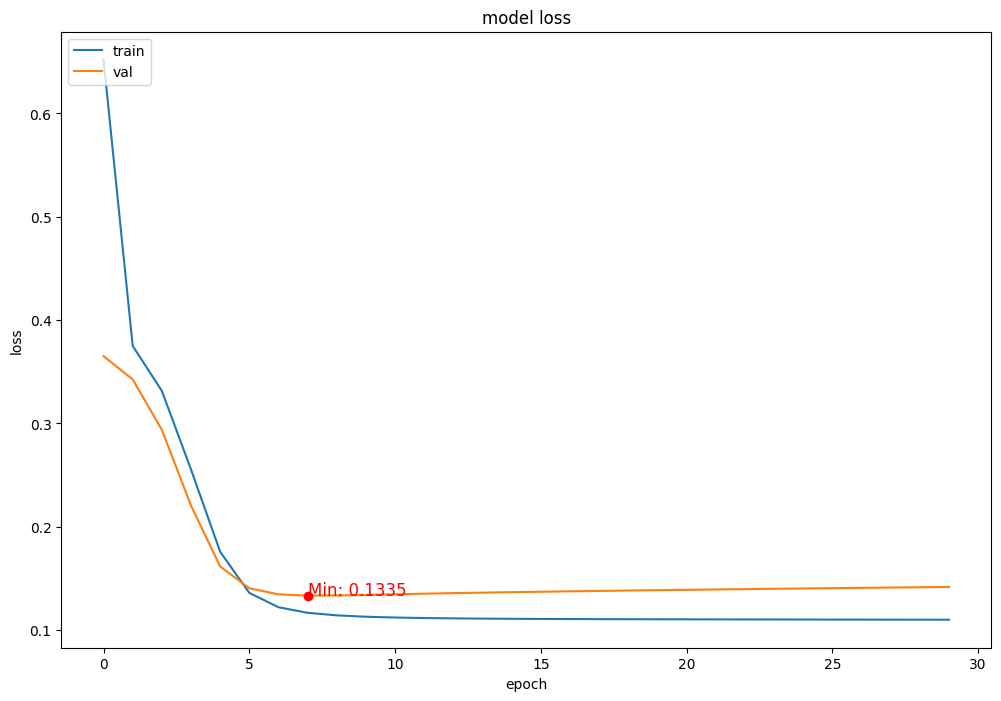

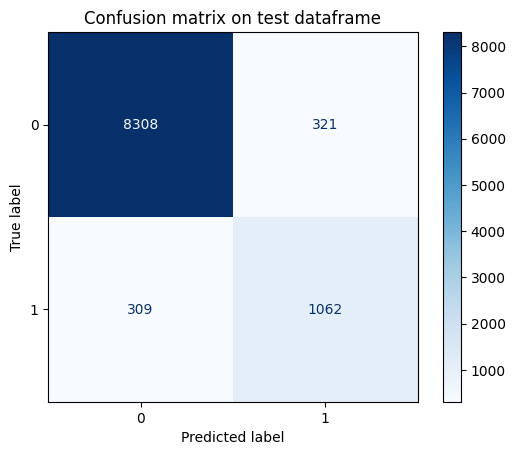

Temps d'exécution : 28 secondes


In [35]:
# Temps d'exécution : 158 secondes
MF_NRS.prediction_score(graph_object, nb_epochs=30, algorithm = "NRS")

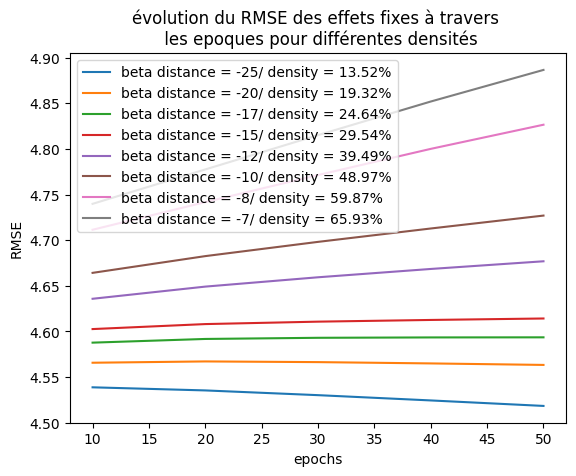

Temps d'exécution : 492 secondes


In [47]:
# Temps d'exécution : 
density_ami_rmse_simulation.plot_rmse_epochs(n=5, save=True, algorithm = "NRS")

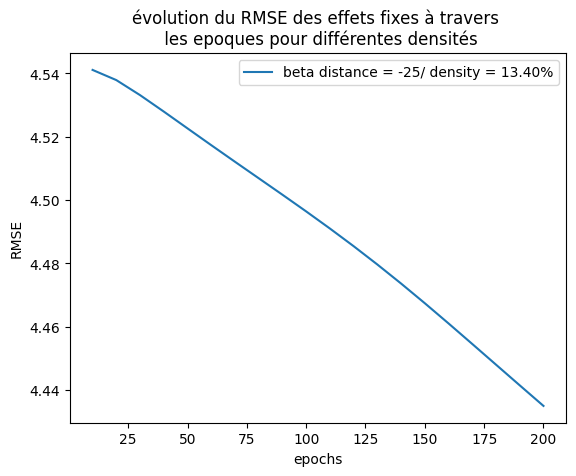

Temps d'exécution : 235 secondes


In [48]:
# Temps d'exécution : 
density_ami_rmse_simulation.plot_rmse_epochs(n = 20, sim_beta_distance_array = [-25], save=True, algorithm = "NRS")

Save done
Temps d'exécution : 578 secondes


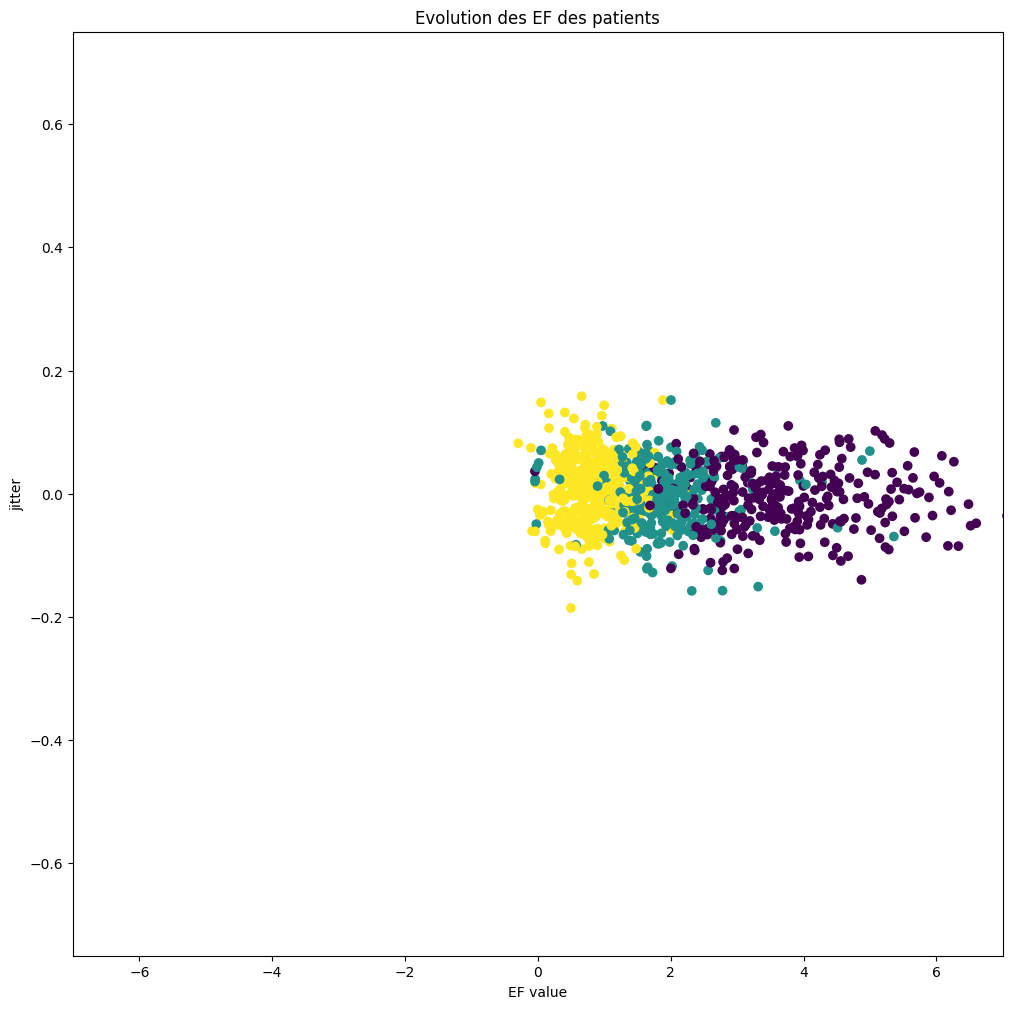

In [49]:
animation.animation_embedding_1D(graph_object, nb_epochs=200, who="patient", algorithm = "NRS")

## Etude avec EF en grande dimension